# 1. Setup and Load Data

###  1.1 Install Dependencies and Setup

In [ ]:
!pip list


In [13]:
import tensorflow as tf
import os

In [12]:
# gpus = tf.config.experimental.list_physical_devices('GPU')

In [13]:
# gpus

In [14]:
# len(gpus)

In [15]:
cpus = tf.config.experimental.list_physical_devices('CPU')

In [16]:
cpus

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [17]:
#Avoid OOM (or and out of memory) errors by setting GPU Memory Consumption Growth

gpus= tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

### 1.2 Remove dodgy images

In [ ]:
import sys
print(sys.executable)
print("Virtual environment:", sys.prefix != sys.base_prefix)

In [29]:
import cv2
from PIL import Image
# from matplotlib import pyplot as plt

In [7]:
data_dir = 'data'

In [ ]:
# os.listdir(os.path.join(data_dir, 'fresh'))

In [8]:
image_exts = ['jpg', 'png', 'jpeg', 'bmp']

In [ ]:
# image_exts[0]

In [25]:
# img= cv2.imread(os.path.join('data', 'fresh', 'ftc-potato-salad-with-chives-07e66d43.jpg'))

In [ ]:
# img.shape

In [ ]:
# type(img)

In [ ]:
# plt.imshow(img)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
for img_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, img_class)):
        image_path = os.path.join(data_dir, img_class, image)

        try:
            img = cv2.imread(image_path)
            # print(img)
            with Image.open(image_path) as pil_image:
                tip = pil_image.format.lower()
                # print(tip)
            if tip not in image_exts:
                print('image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('issues with image {}'.format(image_path)) 
            
            

### 1.3 Load Data

In [ ]:
tf.data.Dataset??


In [35]:
import numpy as np
from matplotlib import pyplot as plt

In [36]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 392 files belonging to 2 classes.


In [37]:
data_iterator = data.as_numpy_iterator()

In [39]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x0000025B3D4E5A90>)

In [52]:
# get another batch from iterator
batch = data_iterator.next()

In [49]:
# Image represented as numpy arrya
batch[0].shape

(32, 256, 256, 3)

In [53]:
# Images labels
# Class 0 = Fresh Potato
# Class 1 = Rotten Potato
batch[1]

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0], dtype=int32)

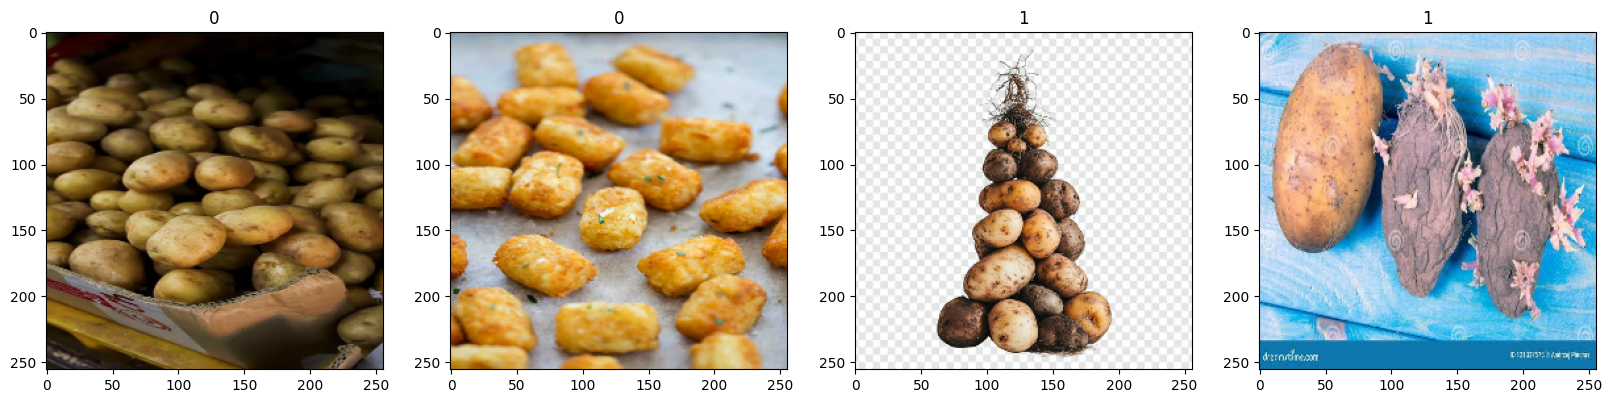

In [54]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])